# Complete Data Unification for Wide&Deep Simulation Recommender

**Goal**: Unify three datasets (AI Career, Career Paths, Skills & Career) into a single dataset for training a Wide&Deep recommender system that recommends **simulations** to students.

**Target**: Predict `simulation_category` (from `categorias_contenido`) based on student profile, skills, and psychometric scores.

**Strategy**: 
- Impute missing psychometric scores using skills/specialization mapping
- Generate missing skills from psychometric profiles
- Infer missing education levels from course complexity
- Map careers to simulation categories

## 1. Setup and Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# Set random seed for reproducibility
np.random.seed(42)

print("✓ Libraries imported successfully")

✓ Libraries imported successfully


## 2. Load Raw Datasets

In [2]:
# Define data directory
data_dir = Path('/workspace/data/raw')

# Load datasets
print("Loading datasets...\n")

df_ai = pd.read_csv(data_dir / 'ai_career.csv')
print(f"✓ AI Career: {df_ai.shape[0]:,} rows × {df_ai.shape[1]} columns")

df_career_paths = pd.read_csv(data_dir / 'career_paths.csv')
print(f"✓ Career Paths: {df_career_paths.shape[0]:,} rows × {df_career_paths.shape[1]} columns")

df_skill_career = pd.read_csv(data_dir / 'skill_career.csv')
print(f"✓ Skills & Career: {df_skill_career.shape[0]:,} rows × {df_skill_career.shape[1]} columns")

print(f"\nTotal raw records: {df_ai.shape[0] + df_career_paths.shape[0] + df_skill_career.shape[0]:,}")

Loading datasets...

✓ AI Career: 200 rows × 8 columns
✓ Career Paths: 5,000 rows × 6 columns
✓ Skills & Career: 3,999 rows × 21 columns

Total raw records: 9,199


## 3. Imputation & Transformation Functions

These functions handle missing data intelligently based on domain knowledge.

### 3.1 Career → Simulation Category Mapping

In [3]:
def map_career_to_simulation_category(career_name):
    """
    Map career/job to simulation category (categorias_contenido)
    Categories: Tecnología, STEM, Negocios, Finanzas, Salud, Legal, Artes, Educación
    """
    career_to_category = {
        # Technology
        'Software Engineer': 'Tecnología',
        'ML Engineer': 'Tecnología',
        'Data Scientist': 'Tecnología',
        'Data Analyst': 'Tecnología',
        'Web Developer': 'Tecnología',
        'DevOps Engineer': 'Tecnología',
        'Cloud Architect': 'Tecnología',
        'AI Researcher': 'Tecnología',
        'System Administrator': 'Tecnología',
        'Database Administrator': 'Tecnología',
        
        # STEM
        'Research Scientist': 'STEM',
        'Astronomer': 'STEM',
        'Geologist': 'STEM',
        'Research analyst': 'STEM',
        'Chemist': 'STEM',
        'Physicist': 'STEM',
        'Biologist': 'STEM',
        
        # Business
        'Marketing Executive': 'Negocios',
        'Business Analyst': 'Negocios',
        'Product Manager': 'Negocios',
        'Project Manager': 'Negocios',
        'Consultant': 'Negocios',
        'Logistics manager': 'Negocios',
        'Clerk': 'Negocios',
        'Marketing': 'Negocios',
        'Operations Manager': 'Negocios',
        'HR Manager': 'Negocios',
        
        # Finance
        'Financial Analyst': 'Finanzas',
        'Accountant': 'Finanzas',
        'Investment Banker': 'Finanzas',
        'Auditor': 'Finanzas',
        'Tax Consultant': 'Finanzas',
        
        # Health
        'Doctor': 'Salud',
        'Nurse': 'Salud',
        'Healthcare Consultant': 'Salud',
        'Medical Researcher': 'Salud',
        'Psychologist': 'Salud',
        'Therapist': 'Salud',
        
        # Legal
        'Lawyer': 'Legal',
        'Legal Consultant': 'Legal',
        'Paralegal': 'Legal',
        
        # Arts
        'Graphic Designer': 'Artes',
        'UX Designer': 'Artes',
        'Content Creator': 'Artes',
        'Artist': 'Artes',
        'Animator': 'Artes',
        
        # Education
        'Teacher': 'Educación',
        'Professor': 'Educación',
        'Trainer': 'Educación',
    }
    
    # Exact match
    if career_name in career_to_category:
        return career_to_category[career_name]
    
    # Fuzzy matching with keywords
    career_lower = str(career_name).lower()
    
    if any(kw in career_lower for kw in ['engineer', 'developer', 'software', 'tech', 'data', 'ml', 'ai', 'programmer']):
        return 'Tecnología'
    elif any(kw in career_lower for kw in ['scientist', 'research', 'science', 'astronomer', 'geologist']):
        return 'STEM'
    elif any(kw in career_lower for kw in ['business', 'manager', 'consultant', 'executive', 'marketing', 'sales']):
        return 'Negocios'
    elif any(kw in career_lower for kw in ['finance', 'accounting', 'banker', 'financial', 'audit']):
        return 'Finanzas'
    elif any(kw in career_lower for kw in ['design', 'creative', 'artist', 'ux', 'ui', 'graphic']):
        return 'Artes'
    elif any(kw in career_lower for kw in ['health', 'medical', 'doctor', 'nurse', 'psych', 'therapy']):
        return 'Salud'
    elif any(kw in career_lower for kw in ['legal', 'lawyer', 'law', 'attorney']):
        return 'Legal'
    elif any(kw in career_lower for kw in ['teacher', 'professor', 'education', 'trainer', 'instructor']):
        return 'Educación'
    else:
        return 'STEM'  # Default

print("✓ Career to simulation category mapping function created")

✓ Career to simulation category mapping function created


### 3.2 Psychometric Scores Imputation from Skills

In [4]:
def impute_psychometric_from_skills(skills_list):
    """
    Generate psychometric scores based on skills profile
    Uses Gardner's Multiple Intelligences framework
    """
    # Initialize with baseline scores
    scores = {
        'linguistic_score': 50,
        'musical_score': 50,
        'bodily_score': 50,
        'logical_math_score': 50,
        'spatial_score': 50,
        'interpersonal_score': 50,
        'intrapersonal_score': 50,
        'naturalist_score': 50
    }
    
    # Skill to intelligence mapping (boosts)
    skill_map = {
        # Technical/Logical
        'python': {'logical_math_score': 25, 'spatial_score': 15},
        'java': {'logical_math_score': 25, 'spatial_score': 10},
        'c++': {'logical_math_score': 30, 'spatial_score': 15},
        'sql': {'logical_math_score': 20, 'spatial_score': 10},
        'data analysis': {'logical_math_score': 25, 'spatial_score': 20},
        'machine learning': {'logical_math_score': 30, 'spatial_score': 20},
        'deep learning': {'logical_math_score': 30, 'spatial_score': 20},
        'statistics': {'logical_math_score': 30, 'naturalist_score': 15},
        'algorithm': {'logical_math_score': 30},
        'cloud computing': {'logical_math_score': 20, 'spatial_score': 10},
        'etl': {'logical_math_score': 20, 'spatial_score': 10},
        
        # Design/Creative/Spatial
        'ux': {'spatial_score': 30, 'intrapersonal_score': 15},
        'design': {'spatial_score': 30, 'intrapersonal_score': 15},
        'graphic': {'spatial_score': 35, 'intrapersonal_score': 10},
        'prototyping': {'spatial_score': 25, 'bodily_score': 15},
        '3d': {'spatial_score': 35, 'bodily_score': 10},
        'visualization': {'spatial_score': 30, 'logical_math_score': 10},
        'interaction': {'spatial_score': 25, 'interpersonal_score': 15},
        
        # Communication/Linguistic
        'communication': {'linguistic_score': 30, 'interpersonal_score': 25},
        'writing': {'linguistic_score': 35, 'intrapersonal_score': 15},
        'copywriting': {'linguistic_score': 30, 'interpersonal_score': 10},
        'speaking': {'linguistic_score': 25, 'interpersonal_score': 30},
        'presentation': {'linguistic_score': 20, 'interpersonal_score': 25},
        'seo': {'linguistic_score': 20, 'logical_math_score': 10},
        
        # Leadership/Interpersonal
        'leadership': {'interpersonal_score': 35, 'intrapersonal_score': 20},
        'teamwork': {'interpersonal_score': 30},
        'project management': {'interpersonal_score': 25, 'logical_math_score': 15},
        'collaboration': {'interpersonal_score': 30},
        'negotiation': {'interpersonal_score': 30, 'linguistic_score': 15},
        
        # Research/Analysis
        'research': {'logical_math_score': 20, 'naturalist_score': 25, 'intrapersonal_score': 15},
        'critical thinking': {'logical_math_score': 25, 'intrapersonal_score': 20},
        'analytical': {'logical_math_score': 25, 'intrapersonal_score': 15},
        
        # Finance/Business
        'financial': {'logical_math_score': 25, 'intrapersonal_score': 10},
        'accounting': {'logical_math_score': 25, 'intrapersonal_score': 10},
        'excel': {'logical_math_score': 15, 'spatial_score': 10},
        'econometrics': {'logical_math_score': 30, 'naturalist_score': 10},
        
        # Technical/Bodily
        'robotics': {'bodily_score': 25, 'logical_math_score': 20, 'spatial_score': 15},
        'iot': {'bodily_score': 20, 'logical_math_score': 25},
        'embedded': {'bodily_score': 20, 'logical_math_score': 25},
        'hardware': {'bodily_score': 25, 'logical_math_score': 15},
    }
    
    # Process skills and accumulate boosts
    if skills_list and len(skills_list) > 0:
        for skill in skills_list:
            skill_lower = str(skill).lower().strip()
            
            # Check each keyword in skill map
            for keyword, boosts in skill_map.items():
                if keyword in skill_lower:
                    for dimension, boost in boosts.items():
                        scores[dimension] += boost
    
    # Cap at 100 and ensure minimum of 20
    for key in scores:
        scores[key] = min(max(scores[key], 20), 100)
    
    return scores

print("✓ Psychometric imputation from skills function created")

✓ Psychometric imputation from skills function created


### 3.3 Psychometric Scores from Specialization (Fallback)

In [5]:
def impute_psychometric_from_specialization(specialization):
    """
    Fallback: use specialization to estimate psychometric profile
    Based on typical profiles for each field
    """
    profiles = {
        'Computer Science': {
            'linguistic_score': 55,
            'musical_score': 45,
            'bodily_score': 40,
            'logical_math_score': 85,
            'spatial_score': 75,
            'interpersonal_score': 60,
            'intrapersonal_score': 65,
            'naturalist_score': 50
        },
        'Engineering': {
            'linguistic_score': 50,
            'musical_score': 45,
            'bodily_score': 65,
            'logical_math_score': 85,
            'spatial_score': 80,
            'interpersonal_score': 60,
            'intrapersonal_score': 60,
            'naturalist_score': 55
        },
        'Business': {
            'linguistic_score': 75,
            'musical_score': 50,
            'bodily_score': 50,
            'logical_math_score': 70,
            'spatial_score': 60,
            'interpersonal_score': 80,
            'intrapersonal_score': 70,
            'naturalist_score': 50
        },
        'Finance': {
            'linguistic_score': 65,
            'musical_score': 45,
            'bodily_score': 45,
            'logical_math_score': 85,
            'spatial_score': 60,
            'interpersonal_score': 70,
            'intrapersonal_score': 65,
            'naturalist_score': 50
        },
        'Psychology': {
            'linguistic_score': 75,
            'musical_score': 55,
            'bodily_score': 50,
            'logical_math_score': 65,
            'spatial_score': 60,
            'interpersonal_score': 90,
            'intrapersonal_score': 85,
            'naturalist_score': 60
        },
        'Arts': {
            'linguistic_score': 80,
            'musical_score': 75,
            'bodily_score': 65,
            'logical_math_score': 50,
            'spatial_score': 85,
            'interpersonal_score': 70,
            'intrapersonal_score': 75,
            'naturalist_score': 55
        },
        'Science': {
            'linguistic_score': 60,
            'musical_score': 45,
            'bodily_score': 55,
            'logical_math_score': 85,
            'spatial_score': 70,
            'interpersonal_score': 60,
            'intrapersonal_score': 70,
            'naturalist_score': 80
        }
    }
    
    # Default profile
    default = {key: 60 for key in ['linguistic_score', 'musical_score', 'bodily_score',
                                     'logical_math_score', 'spatial_score', 'interpersonal_score',
                                     'intrapersonal_score', 'naturalist_score']}
    
    return profiles.get(str(specialization), default)

print("✓ Psychometric imputation from specialization function created")

✓ Psychometric imputation from specialization function created


### 3.4 Generate Skills from Psychometric Profile

In [6]:
def generate_skills_from_psychometric(row):
    """
    Generate likely skills based on high psychometric scores
    """
    skills = []
    
    high_threshold = 75
    very_high_threshold = 85
    
    # Logical-Mathematical → Technical skills
    if row.get('logical_math_score', 0) >= very_high_threshold:
        skills.extend(['Python', 'Data Analysis', 'Problem Solving', 'Algorithm Design'])
    elif row.get('logical_math_score', 0) >= high_threshold:
        skills.extend(['Python', 'Data Analysis'])
    
    # Linguistic → Communication skills
    if row.get('linguistic_score', 0) >= very_high_threshold:
        skills.extend(['Communication', 'Writing', 'Public Speaking', 'Content Creation'])
    elif row.get('linguistic_score', 0) >= high_threshold:
        skills.extend(['Communication', 'Writing'])
    
    # Spatial → Design skills
    if row.get('spatial_score', 0) >= very_high_threshold:
        skills.extend(['Design Thinking', 'Data Visualization', 'UX Design'])
    elif row.get('spatial_score', 0) >= high_threshold:
        skills.extend(['Design Thinking', 'Data Visualization'])
    
    # Interpersonal → Leadership/Team skills
    if row.get('interpersonal_score', 0) >= very_high_threshold:
        skills.extend(['Leadership', 'Teamwork', 'Collaboration', 'Negotiation'])
    elif row.get('interpersonal_score', 0) >= high_threshold:
        skills.extend(['Teamwork', 'Collaboration'])
    
    # Intrapersonal → Self-management
    if row.get('intrapersonal_score', 0) >= very_high_threshold:
        skills.extend(['Self-Management', 'Critical Thinking', 'Strategic Planning'])
    elif row.get('intrapersonal_score', 0) >= high_threshold:
        skills.extend(['Critical Thinking'])
    
    # Naturalist → Science/Research
    if row.get('naturalist_score', 0) >= very_high_threshold:
        skills.extend(['Research', 'Data Collection', 'Statistical Analysis'])
    elif row.get('naturalist_score', 0) >= high_threshold:
        skills.extend(['Research'])
    
    # Musical → Creative/Pattern Recognition
    if row.get('musical_score', 0) >= very_high_threshold:
        skills.extend(['Creative Thinking', 'Pattern Recognition'])
    
    # Bodily → Hands-on/Physical
    if row.get('bodily_score', 0) >= very_high_threshold:
        skills.extend(['Prototyping', 'Technical Skills'])
    
    # Ensure at least some skills
    if len(skills) == 0:
        skills = ['Problem Solving', 'Teamwork', 'Communication']
    
    return list(set(skills))  # Remove duplicates

print("✓ Skills generation from psychometric function created")

✓ Skills generation from psychometric function created


### 3.5 Education Level Inference

In [7]:
def infer_education_level(course_or_context):
    """
    Infer education level from course name or other context
    """
    text = str(course_or_context).lower()
    
    phd_keywords = ['phd', 'doctoral', 'doctorate', 'research', 'thesis', 'dissertation']
    masters_keywords = ['advanced', 'masters', "master's", 'msc', 'mba', 'postgraduate', 'graduate']
    bachelors_keywords = ['bachelor', "bachelor's", 'undergraduate', 'degree', 'engineering', 'university']
    intermediate_keywords = ['intermediate', 'college', 'pre-university', 'high school']
    
    if any(kw in text for kw in phd_keywords):
        return 'PhD'
    elif any(kw in text for kw in masters_keywords):
        return "Master's"
    elif any(kw in text for kw in bachelors_keywords):
        return "Bachelor's"
    elif any(kw in text for kw in intermediate_keywords):
        return 'Intermediate'
    else:
        return "Bachelor's"  # Default

print("✓ Education level inference function created")

✓ Education level inference function created


### 3.6 Specialization Inference from Skills

In [8]:
def infer_specialization_from_skills(skills_list):
    """
    Infer specialization based on dominant skill category
    """
    if not skills_list or len(skills_list) == 0:
        return 'Engineering'  # Default
    
    # Skill categories
    tech_skills = ['python', 'java', 'c++', 'sql', 'javascript', 'html', 'css',
                   'machine learning', 'data analysis', 'cloud', 'programming']
    business_skills = ['marketing', 'finance', 'accounting', 'business', 'management',
                      'strategy', 'sales', 'economics']
    design_skills = ['ux', 'ui', 'design', 'graphic', 'prototyping', 'creative', 'visual']
    science_skills = ['research', 'statistics', 'biology', 'chemistry', 'physics',
                     'environmental', 'scientific']
    psych_skills = ['psychology', 'counseling', 'therapy', 'mental health', 'behavioral']
    
    skills_lower = [str(s).lower() for s in skills_list]
    
    # Count matches
    tech_count = sum(1 for s in skills_lower if any(ts in s for ts in tech_skills))
    business_count = sum(1 for s in skills_lower if any(bs in s for bs in business_skills))
    design_count = sum(1 for s in skills_lower if any(ds in s for ds in design_skills))
    science_count = sum(1 for s in skills_lower if any(ss in s for ss in science_skills))
    psych_count = sum(1 for s in skills_lower if any(ps in s for ps in psych_skills))
    
    # Determine dominant
    counts = {
        'Computer Science': tech_count,
        'Business': business_count,
        'Arts': design_count,
        'Science': science_count,
        'Psychology': psych_count
    }
    
    max_category = max(counts, key=counts.get)
    
    return max_category if counts[max_category] > 0 else 'Engineering'

print("✓ Specialization inference from skills function created")

✓ Specialization inference from skills function created


### 3.7 CGPA Calculation from Performance Scores

In [9]:
def calculate_cgpa_from_performance(row):
    """
    Convert performance ratings (P1-P8) to CGPA score
    """
    perf_cols = ['P1', 'P2', 'P3', 'P4', 'P5', 'P6', 'P7', 'P8']
    perf_map = {'BEST': 90, 'AVG': 70, 'POOR': 50}
    
    scores = []
    for col in perf_cols:
        if col in row and pd.notna(row[col]):
            score = perf_map.get(row[col], None)
            if score is not None:
                scores.append(score)
    
    return np.mean(scores) if len(scores) > 0 else 70.0  # Default

print("✓ CGPA calculation from performance function created")

✓ CGPA calculation from performance function created


### 3.8 Generate Recommendation Score

In [10]:
def generate_recommendation_score(row):
    """
    Generate synthetic recommendation score (0.5-1.0)
    Based on: CGPA (40%) + Skill Match (30%) + Psychometric Fit (30%)
    """
    components = []
    
    # CGPA component
    cgpa = row.get('cgpa_score', 70)
    cgpa_component = (cgpa / 100) * 0.4
    components.append(cgpa_component)
    
    # Skill count component
    skill_count = row.get('skill_count', 3)
    skill_component = min(skill_count / 10, 1.0) * 0.3
    components.append(skill_component)
    
    # Psychometric fit component
    psycho_cols = ['linguistic_score', 'logical_math_score', 'spatial_score',
                   'interpersonal_score', 'intrapersonal_score', 'naturalist_score']
    psycho_scores = [row.get(col, 60) for col in psycho_cols if pd.notna(row.get(col))]
    if psycho_scores:
        psycho_avg = np.mean(psycho_scores)
        psycho_component = (psycho_avg / 100) * 0.3
        components.append(psycho_component)
    
    total = sum(components)
    
    # Add small noise (±5%)
    noise = np.random.uniform(-0.05, 0.05)
    total = max(0.5, min(total + noise, 1.0))
    
    return round(total, 3)

print("✓ Recommendation score generation function created")

✓ Recommendation score generation function created


## 4. Dataset Transformation Functions

### 4.1 Transform AI Career Dataset

In [11]:
def transform_ai_career(df):
    """
    Transform AI Career dataset to unified schema
    Has: Education, Skills, Recommended_Career, Recommendation_Score
    Missing: Psychometric scores, CGPA, Certifications
    """
    print("Transforming AI Career dataset...")
    unified = pd.DataFrame()
    
    # Student ID
    unified['student_id'] = 'AI_' + df['CandidateID'].astype(str)
    
    # Education
    unified['education_level'] = df['Education']
    
    # Skills (split semicolon-separated)
    unified['skills_list'] = df['Skills'].str.split(';')
    unified['skill_count'] = unified['skills_list'].apply(lambda x: len(x) if x else 0)
    
    # Infer specialization from skills
    unified['specialization'] = unified['skills_list'].apply(infer_specialization_from_skills)
    
    # Impute psychometric scores from skills
    print("  → Imputing psychometric scores from skills...")
    psycho_data = unified['skills_list'].apply(impute_psychometric_from_skills)
    for col in ['linguistic_score', 'musical_score', 'bodily_score', 'logical_math_score',
                'spatial_score', 'interpersonal_score', 'intrapersonal_score', 'naturalist_score']:
        unified[col] = psycho_data.apply(lambda x: x[col])
    
    # CGPA (use mean)
    unified['cgpa_score'] = 75.0
    
    # Certifications (empty)
    unified['certifications_list'] = [[] for _ in range(len(df))]
    unified['certification_count'] = 0
    
    # Target: Map career to simulation category
    unified['simulation_category'] = df['Recommended_Career'].apply(map_career_to_simulation_category)
    unified['career_name'] = df['Recommended_Career']
    unified['recommendation_score'] = df['Recommendation_Score']
    
    # Metadata
    unified['source_dataset'] = 'ai_career'
    unified['data_completeness'] = 1.0
    
    print(f"  ✓ Transformed {len(unified):,} records")
    return unified

print("✓ AI Career transformation function created")

✓ AI Career transformation function created


### 4.2 Transform Career Paths Dataset

In [12]:
def transform_career_paths(df):
    """
    Transform Career Paths dataset to unified schema
    Has: Education Level, Specialization, Skills, Certifications, CGPA, Recommended Career
    Missing: Psychometric scores, Recommendation Score
    """
    print("Transforming Career Paths dataset...")
    unified = pd.DataFrame()
    
    # Student ID
    unified['student_id'] = 'CP_' + df.index.astype(str)
    
    # Education
    unified['education_level'] = df['Education Level']
    
    # Specialization
    unified['specialization'] = df['Specialization']
    
    # Skills (single skill per row → convert to list)
    unified['skills_list'] = df['Skills'].apply(lambda x: [str(x)] if pd.notna(x) else [])
    unified['skill_count'] = unified['skills_list'].apply(len)
    
    # Certifications (single cert per row → convert to list)
    unified['certifications_list'] = df['Certifications'].apply(lambda x: [str(x)] if pd.notna(x) else [])
    unified['certification_count'] = unified['certifications_list'].apply(len)
    
    # CGPA
    unified['cgpa_score'] = df['CGPA/Percentage'].fillna(70.0)
    
    # Impute psychometric scores from skills first, then fallback to specialization
    print("  → Imputing psychometric scores from skills and specialization...")
    
    def get_psycho_scores(row):
        if row['skills_list'] and len(row['skills_list']) > 0:
            return impute_psychometric_from_skills(row['skills_list'])
        else:
            return impute_psychometric_from_specialization(row['specialization'])
    
    psycho_data = unified.apply(get_psycho_scores, axis=1)
    for col in ['linguistic_score', 'musical_score', 'bodily_score', 'logical_math_score',
                'spatial_score', 'interpersonal_score', 'intrapersonal_score', 'naturalist_score']:
        unified[col] = psycho_data.apply(lambda x: x[col])
    
    # Target
    unified['simulation_category'] = df['Recommended Career'].apply(map_career_to_simulation_category)
    unified['career_name'] = df['Recommended Career']
    
    # Generate recommendation score
    print("  → Generating recommendation scores...")
    unified['recommendation_score'] = unified.apply(generate_recommendation_score, axis=1)
    
    # Metadata
    unified['source_dataset'] = 'career_paths'
    unified['data_completeness'] = 0.98
    
    print(f"  ✓ Transformed {len(unified):,} records")
    return unified

print("✓ Career Paths transformation function created")

✓ Career Paths transformation function created


### 4.3 Transform Skills & Career Dataset

In [13]:
def transform_skill_career(df):
    """
    Transform Skills & Career dataset to unified schema
    Has: Psychometric scores (8 dimensions), Course, Job profession, Performance scores
    Missing: Education Level, Skills, Certifications, CGPA, Recommendation Score
    """
    print("Transforming Skills & Career dataset...")
    unified = pd.DataFrame()
    
    # Student ID
    unified['student_id'] = 'SC_' + df['Student'].astype(str)
    
    # Psychometric scores (already present!)
    psycho_cols = {
        'Linguistic': 'linguistic_score',
        'Musical': 'musical_score',
        'Bodily': 'bodily_score',
        'Logical - Mathematical': 'logical_math_score',
        'Spatial-Visualization': 'spatial_score',
        'Interpersonal': 'interpersonal_score',
        'Intrapersonal': 'intrapersonal_score',
        'Naturalist': 'naturalist_score'
    }
    
    for old_col, new_col in psycho_cols.items():
        if old_col in df.columns:
            unified[new_col] = df[old_col].fillna(60.0)  # Fill missing with mean
        else:
            unified[new_col] = 60.0
    
    # Specialization from Course
    unified['specialization'] = df['Course'].fillna('Engineering')
    
    # Infer education level from Course
    print("  → Inferring education level from course names...")
    unified['education_level'] = df['Course'].apply(infer_education_level)
    
    # Generate skills from psychometric profile
    print("  → Generating skills from psychometric scores...")
    unified['skills_list'] = unified.apply(generate_skills_from_psychometric, axis=1)
    unified['skill_count'] = unified['skills_list'].apply(len)
    
    # Certifications (empty)
    unified['certifications_list'] = [[] for _ in range(len(df))]
    unified['certification_count'] = 0
    
    # Calculate CGPA from performance scores (P1-P8)
    print("  → Calculating CGPA from performance scores...")
    unified['cgpa_score'] = df.apply(calculate_cgpa_from_performance, axis=1)
    
    # Target
    unified['simulation_category'] = df['Job profession'].apply(map_career_to_simulation_category)
    unified['career_name'] = df['Job profession']
    
    # Generate recommendation score
    print("  → Generating recommendation scores...")
    unified['recommendation_score'] = unified.apply(generate_recommendation_score, axis=1)
    
    # Metadata
    unified['source_dataset'] = 'skill_career'
    unified['data_completeness'] = 0.82
    
    print(f"  ✓ Transformed {len(unified):,} records")
    return unified

print("✓ Skills & Career transformation function created")

✓ Skills & Career transformation function created


## 5. Execute Transformations

In [14]:
print("="*80)
print("EXECUTING DATASET TRANSFORMATIONS")
print("="*80)
print()

# Transform each dataset
df_ai_unified = transform_ai_career(df_ai)
print()

df_career_unified = transform_career_paths(df_career_paths)
print()

df_skill_unified = transform_skill_career(df_skill_career)
print()

print("="*80)
print("TRANSFORMATION COMPLETE")
print("="*80)

EXECUTING DATASET TRANSFORMATIONS

Transforming AI Career dataset...
  → Imputing psychometric scores from skills...
  ✓ Transformed 200 records

Transforming Career Paths dataset...
  → Imputing psychometric scores from skills and specialization...
  → Generating recommendation scores...
  ✓ Transformed 5,000 records

Transforming Skills & Career dataset...
  → Inferring education level from course names...
  → Generating skills from psychometric scores...
  → Calculating CGPA from performance scores...
  → Generating recommendation scores...
  ✓ Transformed 3,999 records

TRANSFORMATION COMPLETE


## 6. Combine All Datasets

In [15]:
print("\nCombining all datasets...")

# Concatenate all three
df_unified = pd.concat([
    df_ai_unified,
    df_career_unified,
    df_skill_unified
], ignore_index=True)

print(f"\n✓ Combined dataset created!")
print(f"  Total records: {len(df_unified):,}")
print(f"  Total columns: {len(df_unified.columns)}")
print(f"\nRecords by source:")
print(df_unified['source_dataset'].value_counts())


Combining all datasets...

✓ Combined dataset created!
  Total records: 9,199
  Total columns: 21

Records by source:
source_dataset
career_paths    5000
skill_career    3999
ai_career        200
Name: count, dtype: int64


## 7. Data Quality Assessment

In [16]:
print("\n" + "="*80)
print("DATA QUALITY ASSESSMENT")
print("="*80)

# Missing values
missing = df_unified.isnull().sum()
missing_pct = (missing / len(df_unified)) * 100

quality_df = pd.DataFrame({
    'Missing_Count': missing,
    'Missing_Pct': missing_pct,
    'Non_Null': len(df_unified) - missing
}).sort_values('Missing_Pct', ascending=False)

print("\nMissing Values Analysis:")
print(quality_df[quality_df['Missing_Count'] > 0])

print(f"\nOverall Completeness: {100 - quality_df['Missing_Pct'].mean():.2f}%")
print(f"Total Missing Values: {quality_df['Missing_Count'].sum():,}")


DATA QUALITY ASSESSMENT

Missing Values Analysis:
             Missing_Count  Missing_Pct  Non_Null
career_name            399     4.337428      8800

Overall Completeness: 99.79%
Total Missing Values: 399


## 8. Preview Unified Dataset

In [17]:
print("\n" + "="*80)
print("UNIFIED DATASET PREVIEW")
print("="*80)

print("\nFirst 10 rows:")
display(df_unified.head(10))

print("\nDataset Info:")
print(df_unified.info())


UNIFIED DATASET PREVIEW

First 10 rows:


,student_id,education_level,skills_list,skill_count,specialization,linguistic_score,musical_score,bodily_score,logical_math_score,spatial_score,interpersonal_score,intrapersonal_score,naturalist_score,cgpa_score,certifications_list,certification_count,simulation_category,career_name,recommendation_score,source_dataset,data_completeness
0,AI_1,Bachelor's,"[Python, Data Analysis, Machine Learning]",3,Computer Science,50.0,50.0,50.0,100.0,100.0,50.0,50.0,50.0,75.0,[],0,Tecnología,Data Scientist,0.95,ai_career,1.0
1,AI_2,Master's,"[Java, System Design, Cloud Computing]",3,Computer Science,50.0,50.0,50.0,95.0,100.0,50.0,65.0,50.0,75.0,[],0,Tecnología,Software Engineer,0.90,ai_career,1.0
2,AI_3,Bachelor's,"[Graphic Design, UI/UX, Adobe Creative Suite]",3,Arts,50.0,50.0,50.0,50.0,100.0,50.0,90.0,50.0,75.0,[],0,Artes,UX Designer,0.88,ai_career,1.0
3,AI_4,Bachelor's,"[Python, Deep Learning, Statistics]",3,Computer Science,50.0,50.0,50.0,100.0,85.0,50.0,50.0,65.0,75.0,[],0,Tecnología,AI Researcher,0.93,ai_career,1.0
4,AI_5,Master's,"[Project Management, Communication, Agile]",3,Business,80.0,50.0,50.0,65.0,50.0,100.0,50.0,50.0,75.0,[],0,Negocios,Project Manager,0.87,ai_career,1.0
5,AI_6,Bachelor's,"[C++, Embedded Systems, IoT]",3,Computer Science,50.0,50.0,90.0,100.0,65.0,50.0,50.0,50.0,75.0,[],0,Tecnología,Embedded Systems Engineer,0.91,ai_career,1.0
6,AI_7,Master's,"[SQL, Data Warehousing, ETL]",3,Computer Science,50.0,50.0,50.0,90.0,70.0,50.0,50.0,50.0,75.0,[],0,Tecnología,Data Analyst,0.89,ai_career,1.0
7,AI_8,Bachelor's,"[Content Writing, SEO, Social Media]",3,Engineering,100.0,50.0,50.0,60.0,50.0,50.0,65.0,50.0,75.0,[],0,STEM,Digital Marketer,0.86,ai_career,1.0
8,AI_9,Bachelor's,"[Python, Natural Language Processing, Machine ...",3,Computer Science,50.0,50.0,50.0,100.0,85.0,50.0,50.0,50.0,75.0,[],0,Tecnología,NLP Engineer,0.92,ai_career,1.0
9,AI_10,Master's,"[Financial Analysis, Excel, Econometrics]",3,Engineering,50.0,50.0,50.0,100.0,60.0,50.0,60.0,60.0,75.0,[],0,Finanzas,Financial Analyst,0.90,ai_career,1.0



Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9199 entries, 0 to 9198
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   student_id            9199 non-null   object 
 1   education_level       9199 non-null   object 
 2   skills_list           9199 non-null   object 
 3   skill_count           9199 non-null   int64  
 4   specialization        9199 non-null   object 
 5   linguistic_score      9199 non-null   float64
 6   musical_score         9199 non-null   float64
 7   bodily_score          9199 non-null   float64
 8   logical_math_score    9199 non-null   float64
 9   spatial_score         9199 non-null   float64
 10  interpersonal_score   9199 non-null   float64
 11  intrapersonal_score   9199 non-null   float64
 12  naturalist_score      9199 non-null   float64
 13  cgpa_score            9199 non-null   float64
 14  certifications_list   9199 non-null   object 
 15  certif

## 9. Statistical Summary

In [18]:
print("\n" + "="*80)
print("STATISTICAL SUMMARY")
print("="*80)

# Numeric columns
numeric_cols = df_unified.select_dtypes(include=[np.number]).columns.tolist()
print("\nNumeric Features:")
display(df_unified[numeric_cols].describe())

# Categorical distributions
print("\nSimulation Category Distribution:")
print(df_unified['simulation_category'].value_counts())

print("\nEducation Level Distribution:")
print(df_unified['education_level'].value_counts())

print("\nSpecialization Distribution:")
print(df_unified['specialization'].value_counts())


STATISTICAL SUMMARY

Numeric Features:


,skill_count,linguistic_score,musical_score,bodily_score,logical_math_score,spatial_score,interpersonal_score,intrapersonal_score,naturalist_score,cgpa_score,certification_count,recommendation_score,data_completeness
count,9199.000000,9199.000000,9199.000000,9199.000000,9199.000000,9199.000000,9199.000000,9199.000000,9199.000000,9199.000000,9199.000000,9199.000000,9199.000000
mean,1.913143,39.246222,34.599196,35.641809,53.019133,42.240135,39.654528,38.990216,35.257963,74.567003,0.478748,0.527984,0.910879
std,0.996602,22.953926,20.372160,19.228993,33.052490,27.772165,20.865232,20.080738,19.749251,8.480968,0.499575,0.063792,0.079753
min,1.000000,5.000000,5.000000,5.000000,5.000000,5.000000,2.000000,5.000000,0.000000,60.000000,0.000000,0.500000,0.820000
25%,1.000000,14.000000,9.000000,14.000000,18.000000,11.000000,18.000000,17.000000,13.000000,70.000000,0.000000,0.500000,0.820000
50%,1.000000,50.000000,50.000000,50.000000,60.000000,50.000000,50.000000,50.000000,50.000000,72.500000,0.000000,0.500000,0.980000
75%,3.000000,50.000000,50.000000,50.000000,75.000000,65.000000,50.000000,60.000000,50.000000,79.000000,1.000000,0.537000,0.980000
max,4.000000,100.000000,60.000000,90.000000,100.000000,100.000000,100.000000,95.000000,75.000000,95.000000,1.000000,0.950000,1.000000



Simulation Category Distribution:
simulation_category
STEM          3943
Negocios      2041
Tecnología    1616
Educación      607
Finanzas       571
Salud          200
Artes          171
Legal           50
Name: count, dtype: int64

Education Level Distribution:
education_level
Bachelor's      5112
Master's        1100
Matric          1014
PhD             1000
Intermediate     973
Name: count, dtype: int64

Specialization Distribution:
specialization
Engineering         4687
Computer Science     741
Finance              659
Psychology           657
Business             655
Arts                 630
Commerce             601
Science              569
Name: count, dtype: int64


## 10. Visualization: Psychometric Scores Distribution

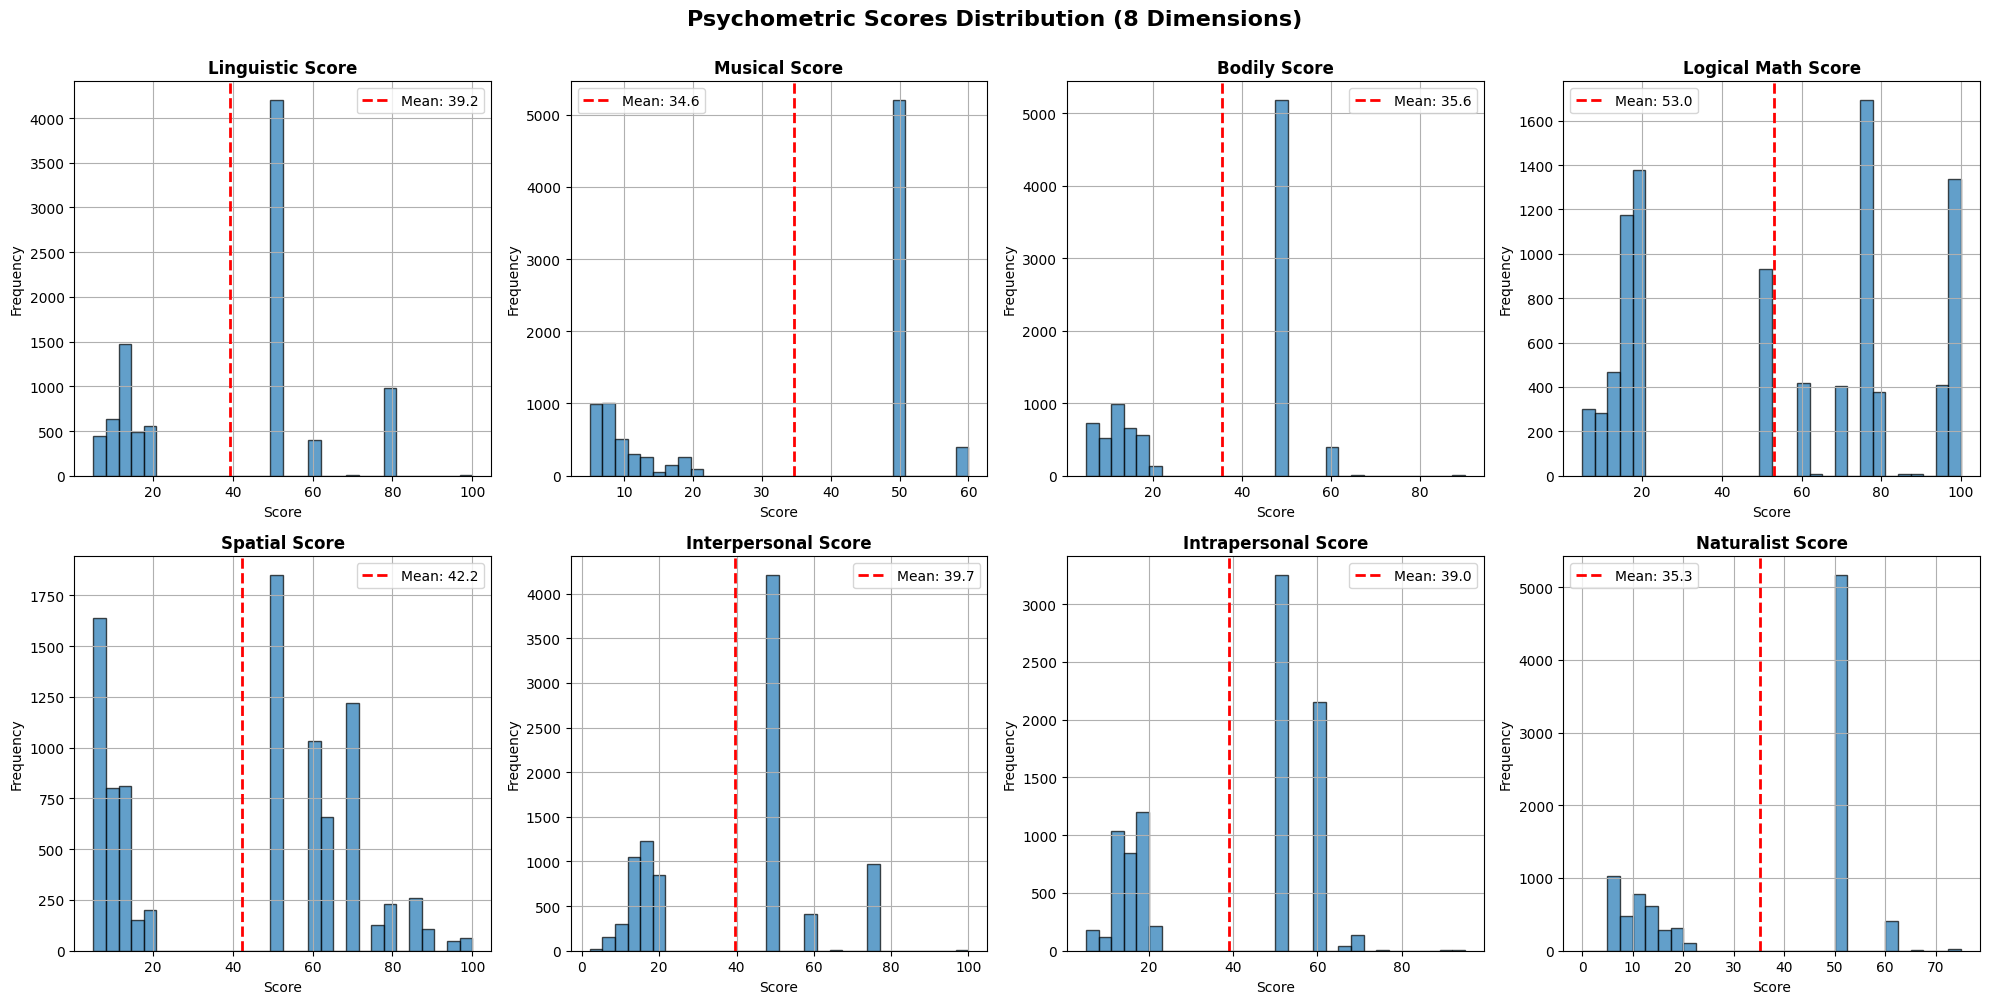

In [19]:
psycho_cols = ['linguistic_score', 'musical_score', 'bodily_score', 'logical_math_score',
               'spatial_score', 'interpersonal_score', 'intrapersonal_score', 'naturalist_score']

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for idx, col in enumerate(psycho_cols):
    df_unified[col].hist(bins=30, ax=axes[idx], edgecolor='black', alpha=0.7)
    axes[idx].set_title(f'{col.replace("_", " ").title()}', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Score')
    axes[idx].set_ylabel('Frequency')
    axes[idx].axvline(df_unified[col].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {df_unified[col].mean():.1f}')
    axes[idx].legend()

plt.suptitle('Psychometric Scores Distribution (8 Dimensions)', fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

## 11. Visualization: Simulation Categories by Education Level

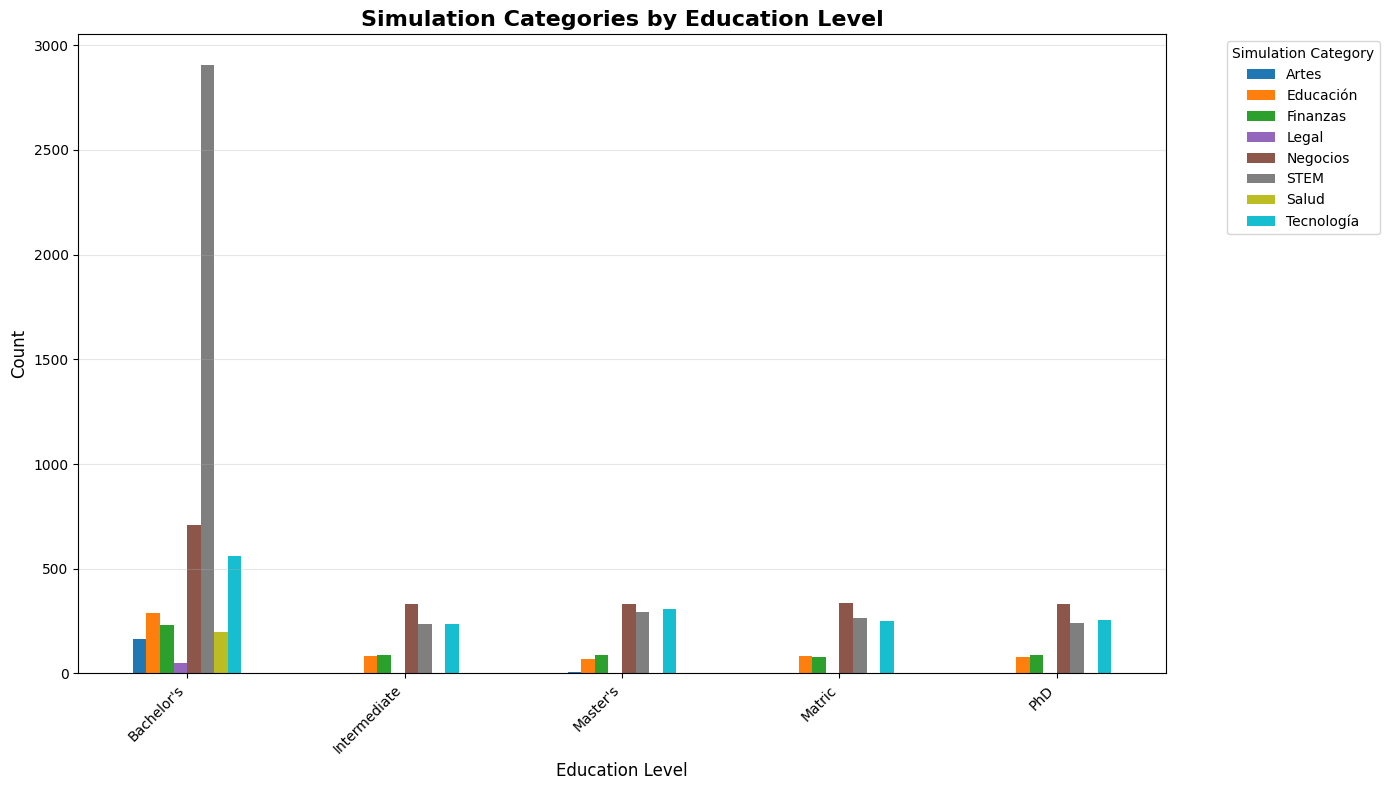

In [20]:
# Create crosstab
ct = pd.crosstab(df_unified['education_level'], df_unified['simulation_category'])

# Plot
fig, ax = plt.subplots(figsize=(14, 8))
ct.plot(kind='bar', stacked=False, ax=ax, colormap='tab10')
ax.set_title('Simulation Categories by Education Level', fontsize=16, fontweight='bold')
ax.set_xlabel('Education Level', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.legend(title='Simulation Category', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(axis='y', alpha=0.3)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 12. Visualization: Skill Count Distribution by Source

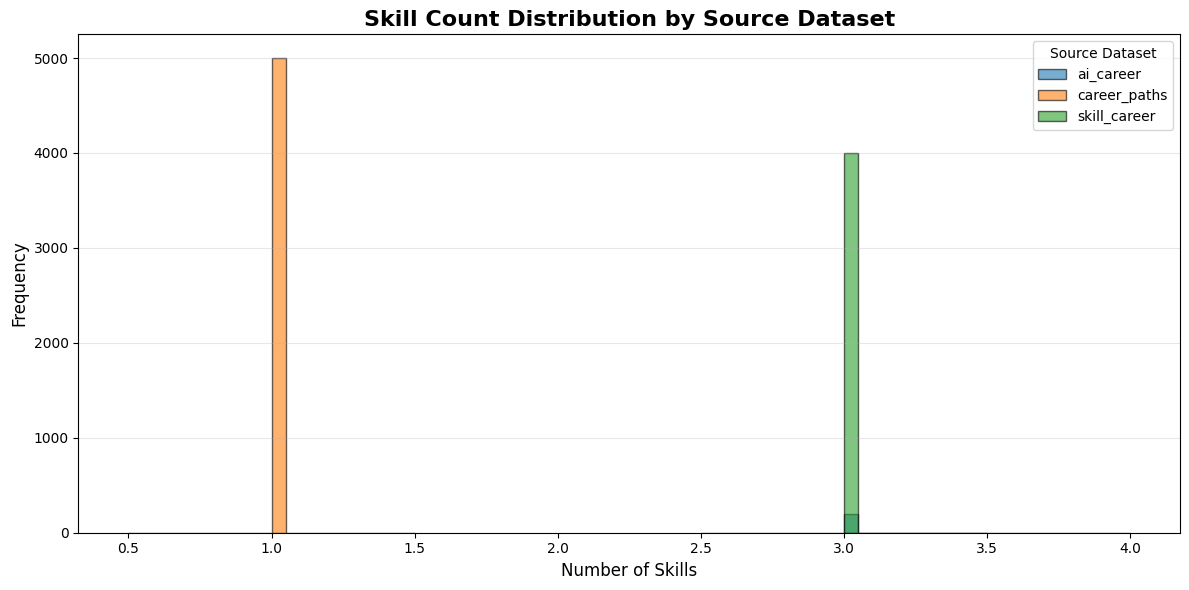

In [21]:
fig, ax = plt.subplots(figsize=(12, 6))

for source in df_unified['source_dataset'].unique():
    data = df_unified[df_unified['source_dataset'] == source]['skill_count']
    ax.hist(data, bins=20, alpha=0.6, label=source, edgecolor='black')

ax.set_title('Skill Count Distribution by Source Dataset', fontsize=16, fontweight='bold')
ax.set_xlabel('Number of Skills', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.legend(title='Source Dataset')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 13. Visualization: CGPA vs Recommendation Score

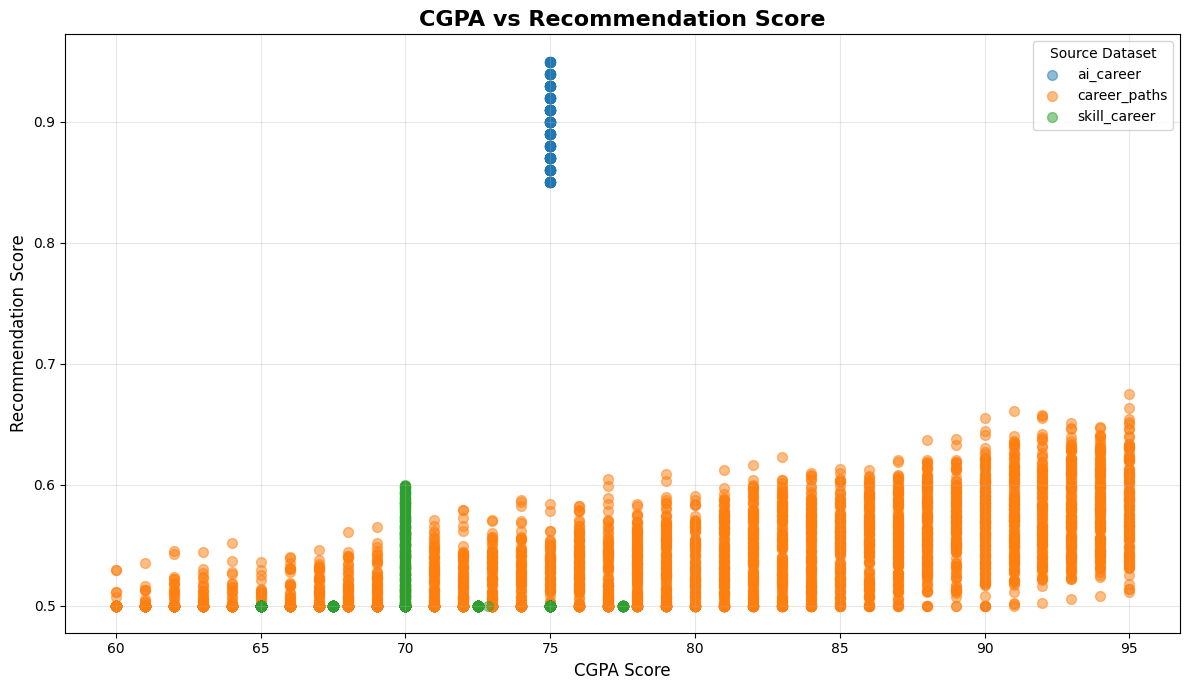

In [22]:
fig, ax = plt.subplots(figsize=(12, 7))

# Scatter plot with color by source
for source in df_unified['source_dataset'].unique():
    data = df_unified[df_unified['source_dataset'] == source]
    ax.scatter(data['cgpa_score'], data['recommendation_score'], 
              alpha=0.5, s=50, label=source)

ax.set_title('CGPA vs Recommendation Score', fontsize=16, fontweight='bold')
ax.set_xlabel('CGPA Score', fontsize=12)
ax.set_ylabel('Recommendation Score', fontsize=12)
ax.legend(title='Source Dataset')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 14. Top Skills Analysis


TOP SKILLS ANALYSIS

Top 20 Most Common Skills:


,Skill,Count
0,Communication,4167
1,Teamwork,3999
2,Problem Solving,3999
3,Python,254
4,Accounting,204
5,SQL,188
6,Data Analysis,185
7,Financial Analysis,182
8,Machine Learning,178
9,Marketing,168


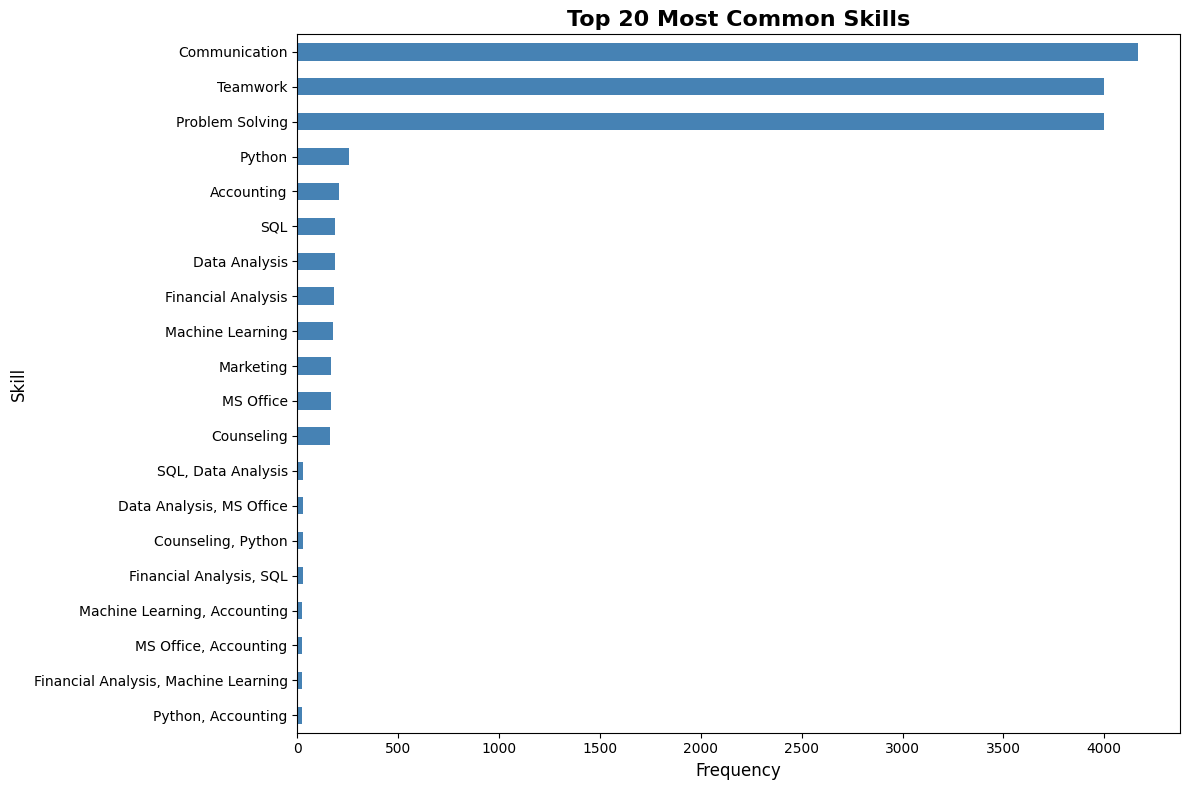

In [23]:
print("\n" + "="*80)
print("TOP SKILLS ANALYSIS")
print("="*80)

# Flatten all skills
all_skills = []
for skills_list in df_unified['skills_list']:
    if skills_list:
        all_skills.extend(skills_list)

# Count frequency
from collections import Counter
skill_counts = Counter(all_skills)

print("\nTop 20 Most Common Skills:")
top_20_skills = pd.DataFrame(skill_counts.most_common(20), columns=['Skill', 'Count'])
display(top_20_skills)

# Visualize
fig, ax = plt.subplots(figsize=(12, 8))
top_20_skills.plot(kind='barh', x='Skill', y='Count', ax=ax, legend=False, color='steelblue')
ax.set_title('Top 20 Most Common Skills', fontsize=16, fontweight='bold')
ax.set_xlabel('Frequency', fontsize=12)
ax.set_ylabel('Skill', fontsize=12)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 15. Save Unified Dataset

In [24]:
print("\n" + "="*80)
print("SAVING UNIFIED DATASET")
print("="*80)

# Define output directory
output_dir = Path('/workspace/data/processed')
output_dir.mkdir(parents=True, exist_ok=True)

# Save as CSV
output_file = output_dir / 'unified_dataset_for_wide_deep.csv'
df_unified.to_csv(output_file, index=False)

print(f"\n✓ Unified dataset saved to: {output_file}")
print(f"  Size: {output_file.stat().st_size / 1024 / 1024:.2f} MB")
print(f"  Records: {len(df_unified):,}")
print(f"  Columns: {len(df_unified.columns)}")

# Also save metadata
metadata = {
    'total_records': len(df_unified),
    'total_columns': len(df_unified.columns),
    'source_breakdown': df_unified['source_dataset'].value_counts().to_dict(),
    'simulation_categories': df_unified['simulation_category'].unique().tolist(),
    'education_levels': df_unified['education_level'].unique().tolist(),
    'specializations': df_unified['specialization'].unique().tolist(),
    'avg_recommendation_score': float(df_unified['recommendation_score'].mean()),
    'avg_cgpa': float(df_unified['cgpa_score'].mean()),
    'avg_skill_count': float(df_unified['skill_count'].mean()),
    'overall_completeness': float(100 - ((df_unified.isnull().sum().sum() / (len(df_unified) * len(df_unified.columns))) * 100))
}

import json
metadata_file = output_dir / 'unified_dataset_metadata.json'
with open(metadata_file, 'w') as f:
    json.dump(metadata, f, indent=2)

print(f"\n✓ Metadata saved to: {metadata_file}")


SAVING UNIFIED DATASET

✓ Unified dataset saved to: /workspace/data/processed/unified_dataset_for_wide_deep.csv
  Size: 1.52 MB
  Records: 9,199
  Columns: 21

✓ Metadata saved to: /workspace/data/processed/unified_dataset_metadata.json


In [ ]:
unified_schema = {
    # ===== STUDENT PROFILE =====
    'student_id': 'string',
    'education_level': 'categorical',
    'specialization': 'categorical',
    'cgpa_score': 'numeric',
    
    # ===== SKILLS =====
    'skills_list': 'multi-hot',
    'skill_count': 'numeric',
    'has_technical_skills': 'binary',
    'has_soft_skills': 'binary',
    
    # ===== PSYCHOMETRIC PROFILE =====
    'linguistic_score': 'numeric',
    'logical_math_score': 'numeric',
    'spatial_score': 'numeric',
    'interpersonal_score': 'numeric',
    'intrapersonal_score': 'numeric',
    'naturalist_score': 'numeric',
    'musical_score': 'numeric',
    'bodily_score': 'numeric',
    
    # ===== CERTIFICATIONS =====
    'certifications_list': 'multi-hot',
    'certification_count': 'numeric',
    
    # ===== TARGET - SIMULATION CATEGORY =====
    'simulation_category': 'categorical',  # ← CHANGED from recommended_career
    'category_name': 'string',             # ← Name of the category (almost career-like)
    'recommendation_score': 'numeric',
    
    # ===== METADATA =====
    'source_dataset': 'categorical',
    'data_completeness': 'numeric'
}

## 16. Final Summary

In [25]:
print("\n" + "="*80)
print("FINAL SUMMARY")
print("="*80)

print(f"\n📊 UNIFIED DATASET STATISTICS:")
print(f"   Total Records: {len(df_unified):,}")
print(f"   Total Features: {len(df_unified.columns)}")
print(f"   Overall Completeness: {metadata['overall_completeness']:.2f}%")

print(f"\n📈 SOURCE DISTRIBUTION:")
for source, count in df_unified['source_dataset'].value_counts().items():
    pct = (count / len(df_unified)) * 100
    print(f"   {source}: {count:,} ({pct:.1f}%)")

print(f"\n🎯 TARGET DISTRIBUTION (Simulation Categories):")
for cat, count in df_unified['simulation_category'].value_counts().head(10).items():
    pct = (count / len(df_unified)) * 100
    print(f"   {cat}: {count:,} ({pct:.1f}%)")

print(f"\n🎓 EDUCATION DISTRIBUTION:")
for edu, count in df_unified['education_level'].value_counts().items():
    pct = (count / len(df_unified)) * 100
    print(f"   {edu}: {count:,} ({pct:.1f}%)")

print(f"\n💡 KEY METRICS:")
print(f"   Average Recommendation Score: {metadata['avg_recommendation_score']:.3f}")
print(f"   Average CGPA: {metadata['avg_cgpa']:.2f}")
print(f"   Average Skills per Student: {metadata['avg_skill_count']:.1f}")

print(f"\n✅ IMPUTATION SUMMARY:")
print(f"   • Psychometric scores imputed for AI Career ({len(df_ai):,} records) and Career Paths ({len(df_career_paths):,} records)")
print(f"   • Skills generated from psychometric profile for Skills & Career ({len(df_skill_career):,} records)")
print(f"   • Education levels inferred for Skills & Career ({len(df_skill_career):,} records)")
print(f"   • CGPA calculated from performance scores for Skills & Career ({len(df_skill_career):,} records)")
print(f"   • Recommendation scores generated for Career Paths ({len(df_career_paths):,} records) and Skills & Career ({len(df_skill_career):,} records)")

print(f"\n🚀 NEXT STEPS:")
print(f"   1. Feature engineering for Wide & Deep model")
print(f"   2. Create multi-hot encodings for skills and certifications")
print(f"   3. Define Wide features (cross-products) and Deep features (embeddings)")
print(f"   4. Train Wide & Deep recommender to predict simulation_category")
print(f"   5. Evaluate model and generate top-N simulation recommendations per student")

print("\n" + "="*80)
print("✓ DATA UNIFICATION COMPLETE!")
print("="*80)


FINAL SUMMARY

📊 UNIFIED DATASET STATISTICS:
   Total Records: 9,199
   Total Features: 21
   Overall Completeness: 99.79%

📈 SOURCE DISTRIBUTION:
   career_paths: 5,000 (54.4%)
   skill_career: 3,999 (43.5%)
   ai_career: 200 (2.2%)

🎯 TARGET DISTRIBUTION (Simulation Categories):
   STEM: 3,943 (42.9%)
   Negocios: 2,041 (22.2%)
   Tecnología: 1,616 (17.6%)
   Educación: 607 (6.6%)
   Finanzas: 571 (6.2%)
   Salud: 200 (2.2%)
   Artes: 171 (1.9%)
   Legal: 50 (0.5%)

🎓 EDUCATION DISTRIBUTION:
   Bachelor's: 5,112 (55.6%)
   Master's: 1,100 (12.0%)
   Matric: 1,014 (11.0%)
   PhD: 1,000 (10.9%)
   Intermediate: 973 (10.6%)

💡 KEY METRICS:
   Average Recommendation Score: 0.528
   Average CGPA: 74.57
   Average Skills per Student: 1.9

✅ IMPUTATION SUMMARY:
   • Psychometric scores imputed for AI Career (200 records) and Career Paths (5,000 records)
   • Skills generated from psychometric profile for Skills & Career (3,999 records)
   • Education levels inferred for Skills & Career (3,